In [1]:
import ssl

ssl._create_default_https_context = ssl._create_stdlib_context

In [2]:
import copy

import earthkit.plots
import numpy as np
import xarray as xr

In [3]:
# TODO: rename
ERA5 = (
    xr.open_mfdataset(
        "/Users/junityre/Downloads/ifs_fesom_story_o25-1_juniper/20240530/*.nc",
        engine="netcdf4",
    )
    .sel(
        # TODO: compress all
        time=slice("2024-05-30T12", "2024-05-30T12"),
    )
    .rename_vars({"2d": "d2m", "2t": "t2m"})
)

In [4]:
def humindex(ERA5):
    assert ERA5.t2m.units == "K"
    assert ERA5.d2m.units == "K"

    ty = ERA5.t2m.dtype.type

    t2m_C = ERA5.t2m - ty(273.15)
    d2m_K = ERA5.d2m

    e = ty(6.11) * np.exp(
        ty(5417.7530) * (np.reciprocal(ty(273.16)) - np.reciprocal(d2m_K))
    )

    hi = t2m_C + ty(0.5555) * (e - ty(10.0))

    return hi.assign_attrs(units="degC", GRIB_units="degC", long_name="Humidex")

In [5]:
def humidex_scale(hu):
    scale = np.zeros_like(hu)
    scale[hu >= 45.5] = 4
    scale[hu < 45.5] = 3
    scale[hu < 39.5] = 2
    scale[hu < 29.5] = 1
    scale[hu < 19.5] = 0
    return scale

In [6]:
ERA5_DT = np.stack([ERA5["d2m"].values, ERA5["t2m"].values], axis=0)
ERA5.d2m.dims, ERA5_DT.shape

(('time', 'lat', 'lon'), (2, 1, 3601, 7200))

In [7]:
eb_abs = 0.1

In [8]:
from numcodecs_wasm_sz3 import Sz3

sz3 = Sz3(eb_mode="abs", eb_abs=eb_abs)

ERA5_DT_sz3_enc = sz3.encode(ERA5_DT)
ERA5_DT_sz3 = sz3.decode(ERA5_DT_sz3_enc)

ERA5_sz3 = ERA5.copy(data=dict(d2m=ERA5_DT_sz3[0], t2m=ERA5_DT_sz3[1]))
ERA5_sz3_cr = ERA5_DT.nbytes / ERA5_DT_sz3_enc.nbytes

In [9]:
from numcodecs_safeguards import SafeguardedCodec

sg_sz3 = SafeguardedCodec(
    codec=sz3,
    safeguards=[
        dict(kind="eb", type="abs", eb=eb_abs),
        dict(
            kind="qoi_eb_stencil",
            qoi="""
        V["t2m_C"] = X[1] - 273.15;
        V["d2m_K"] = X[0];

        V["e"] = 6.11 * exp(5417.7530 * (reciprocal(273.16) - reciprocal(V["d2m_K"])));
        V["hi"] = V["t2m_C"] + 0.5555 * (V["e"] - 10.0);

        V["scale"] = where(
            # > 45: dangerous
            V["hi"] >= 45.5, 4, where(
            # 40-45: great discomfort
            V["hi"] >= 39.5, 3, where(
            # 30-39: some discomfort
            V["hi"] >= 29.5, 2, where(
            # 20-29: little to no discomfort
            V["hi"] >= 19.5, 1,
            # < 20
            0,
        ))));

        return V["scale"];
        """,
            neighbourhood=[
                dict(axis=0, before=0, after=1, boundary="valid"),
            ],
            type="abs",
            eb=0,
        ),
    ],
)

ERA5_DT_sg_sz3_enc = sg_sz3.encode(ERA5_DT)
ERA5_DT_sg_sz3 = sg_sz3.decode(ERA5_DT_sg_sz3_enc)

ERA5_sg_sz3 = ERA5.copy(data=dict(d2m=ERA5_DT_sg_sz3[0], t2m=ERA5_DT_sg_sz3[1]))
ERA5_sg_sz3_cr = ERA5_DT.nbytes / np.asarray(ERA5_DT_sg_sz3_enc).nbytes

In [10]:
ERA5_hu = humindex(ERA5)
ERA5_sz3_hu = humindex(ERA5_sz3)
ERA5_sg_sz3_hu = humindex(ERA5_sg_sz3)

In [11]:
old_cmap_and_norm = earthkit.plots.styles.colors.cmap_and_norm

In [12]:
def my_cmap_and_norm(colors, levels, normalize=True, extend=None, extend_levels=True):
    return old_cmap_and_norm(colors, levels, normalize, extend, True)


earthkit.plots.styles.colors.cmap_and_norm = my_cmap_and_norm

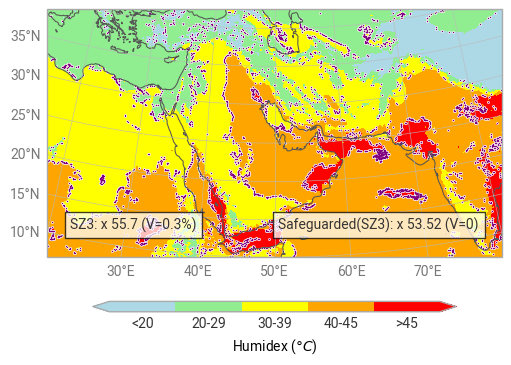

In [13]:
fig = earthkit.plots.Figure(
    size=(5, 5),
    rows=1,
    columns=1,
)

domain = earthkit.plots.geo.domains.Domain.from_bbox(bbox=[20, 80, 10, 40])

chart = fig.add_map(0, 0, domain=domain)

da = humindex(ERA5.sel(time="2024-05-30T12"))

# compute the default style that earthkit.maps would apply
source = earthkit.plots.sources.XarraySource(da)
style = copy.deepcopy(
    earthkit.plots.styles.auto.guess_style(
        source,
        units=source.units,
    )
)
style._colors = ["lightblue", "lightgreen", "yellow", "orange", "red"]
style._levels = earthkit.plots.styles.levels.Levels([15, 19.5, 29.5, 39.5, 45.5, 50])
style._legend_kwargs["ticks"] = [
    (15 + 19.5) / 2,
    (19.5 + 29.5) / 2,
    (29.5 + 39.5) / 2,
    (39.5 + 45.5) / 2,
    (45.5 + 50) / 2,
]
style._legend_kwargs["extend"] = "both"

chart.pcolormesh(da, style=style)

is_error = humidex_scale(ERA5_hu.sel(time="2024-05-30T12")) != humidex_scale(
    ERA5_sz3_hu.sel(time="2024-05-30T12")
)
error_lons = np.extract(
    is_error, np.broadcast_to(da.lon.values.reshape(1, -1), da.shape)
)
error_lats = np.extract(
    is_error, np.broadcast_to(da.lat.values.reshape(-1, 1), da.shape)
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="white",
    s=2,
    legend_style=None,
    marker="o",
)
chart.point_cloud(
    x=error_lons,
    y=error_lats,
    c="purple",
    s=1,
    legend_style=None,
    marker=".",
)

err_v_sz3 = np.mean(humidex_scale(ERA5_hu) != humidex_scale(ERA5_sz3_hu))
err_v_sg_sz3 = np.mean(humidex_scale(ERA5_hu) != humidex_scale(ERA5_sg_sz3_hu))

t = chart.ax.text(
    0.05,
    0.1,
    (
        f"SZ3: x {np.round(ERA5_sz3_cr, 2)} "
        + f"(V={0 if err_v_sz3 == 0 else np.format_float_positional(100 * err_v_sz3, precision=1, min_digits=1) + '%'})"
    ),
    ha="left",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

t = chart.ax.text(
    0.95,
    0.1,
    (
        f"Safeguarded(SZ3): x {np.round(ERA5_sg_sz3_cr, 2)} "
        + f"(V={0 if err_v_sg_sz3 == 0 else np.format_float_positional(100 * err_v_sg_sz3, precision=1, min_digits=1) + '%'})"
    ),
    ha="right",
    va="bottom",
    transform=chart.ax.transAxes,
)
t.set_bbox(dict(facecolor="white", alpha=0.75, edgecolor="black"))

for m in earthkit.plots.schemas.schema.quickmap_subplot_workflow:
    if m != "title":
        getattr(chart, m)()

for m in earthkit.plots.schemas.schema.quickmap_figure_workflow:
    if m != "legend":
        getattr(chart, m)()

chart.legend()

cb = chart.ax.collections[0].colorbar
cb.ax.set_xticklabels(["<20", "20-29", "30-39", "40-45", ">45"])

fig.show()